### Install packages

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib fastapi uvicorn mysql-connector-python jinja2 python-multipart

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Understanding

### Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv("student_placement_prediction_dataset_2026.csv")

df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


### Check Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

### Dataset Columns

In [4]:
df.columns

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

### Missing Values

In [5]:
df.isnull().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [6]:
df['placement_status'].value_counts()

placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

### Visualization

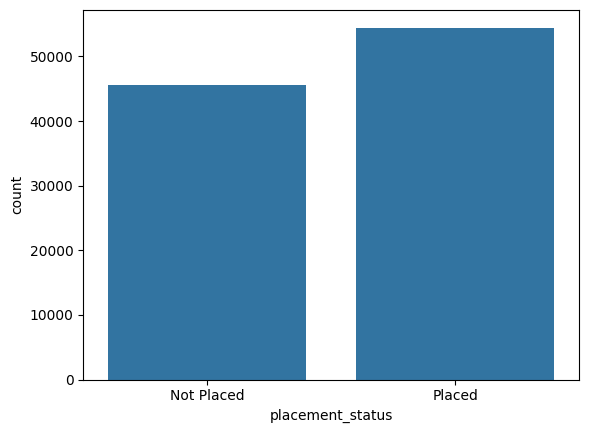

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='placement_status', data=df)
plt.show()

### CGPA vs Placement

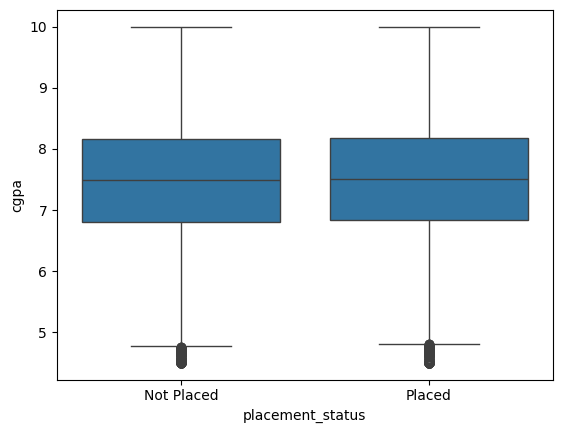

In [8]:
sns.boxplot(
    x='placement_status',
    y='cgpa',
    data=df
)
plt.show()

### Correlation

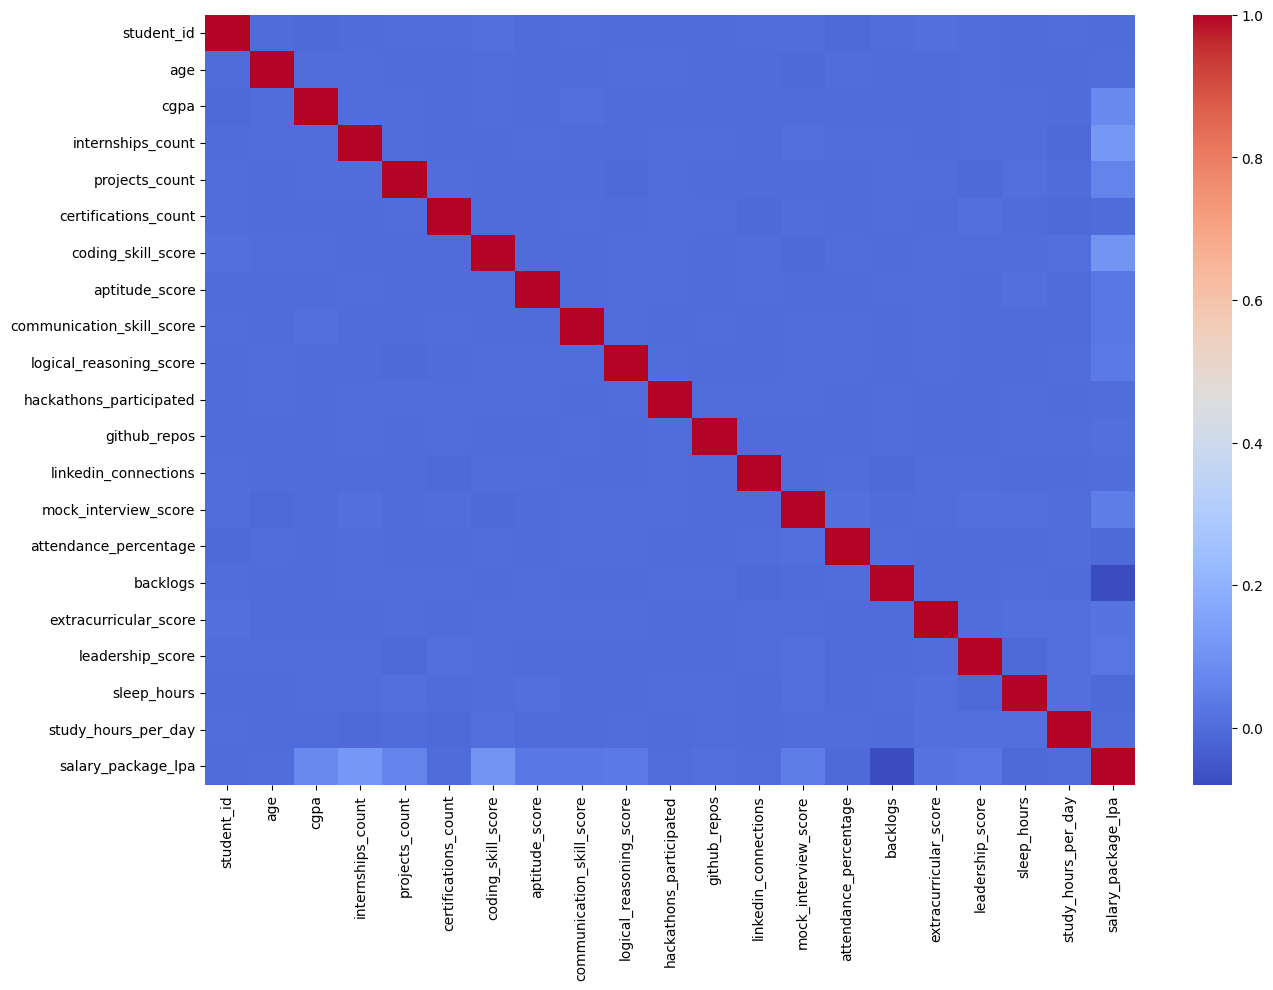

In [9]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm')
plt.show()

# Data Preprocessing

### Separate Features and Target

In [49]:
X = df.drop(
    columns=[
        "placement_status",
        "student_id",
        "salary_package_lpa"
    ]
)

y = df["placement_status"]

### Categorical Columns

In [50]:
categorical_cols = [
    'gender',
    'branch',
    'college_tier',
    'volunteer_experience'
]

### Numerical Columns

In [51]:
numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

# Encoding + Scaling

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### Preprocessor

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numerical_cols
        )
    ]
)

# Train-Test Split

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model Training

### Start with Random Forest

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

### Pipeline

In [56]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     RandomForestClassifier(
         n_estimators=200,
         random_state=42
     ))
])

### Train

In [57]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

# Model Evaluation

### Predictions

In [58]:
y_pred = model.predict(X_test)

### Metrics

In [59]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

### Accuracy

In [60]:
accuracy_score(y_test, y_pred)

0.5587

### Report

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Not Placed       0.52      0.33      0.40      9108
      Placed       0.57      0.75      0.65     10892

    accuracy                           0.56     20000
   macro avg       0.55      0.54      0.53     20000
weighted avg       0.55      0.56      0.54     20000



### Confusion Matrix

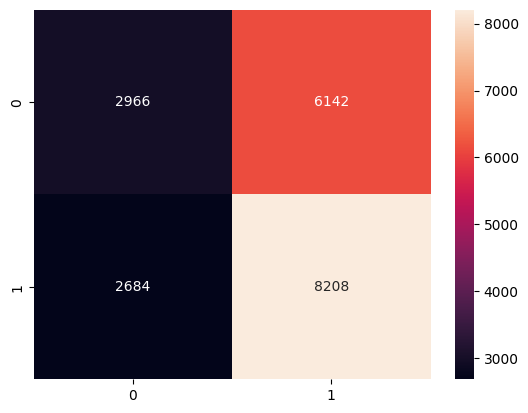

In [62]:
sns.heatmap(
    confusion_matrix(y_test,y_pred),
    annot=True,
    fmt='d'
)
plt.show()

# Save Model

In [63]:
import joblib

joblib.dump(
    model,
    "../model/placement_model.pkl"
)

['../model/placement_model.pkl']

In [64]:
rf = model.named_steps["classifier"]

In [65]:
importances = rf.feature_importances_

In [66]:
feature_names = (
model.named_steps["preprocessor"]
.get_feature_names_out()
)

In [67]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
25,num__mock_interview_score,0.064769
18,num__coding_skill_score,0.064731
21,num__logical_reasoning_score,0.063739
19,num__aptitude_score,0.063520
20,num__communication_skill_score,0.063447
29,num__leadership_score,0.062753
28,num__extracurricular_score,0.062211
24,num__linkedin_connections,0.061793
14,num__cgpa,0.060687
26,num__attendance_percentage,0.060005


<Axes: xlabel='Importance', ylabel='Feature'>

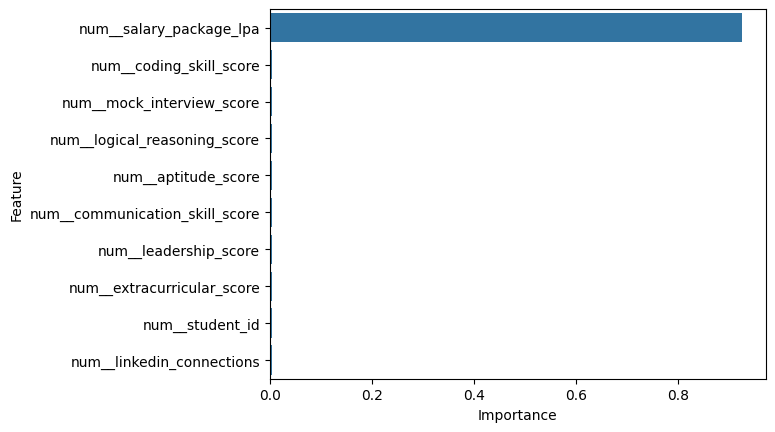

In [41]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.sort_values(
        by="Importance",
        ascending=False
    ).head(10)
)

In [68]:
print(df["gender"].unique())
print(df["branch"].unique())
print(df["college_tier"].unique())
print(df["volunteer_experience"].unique())

['Male' 'Female']
['IT' 'CSE' 'EEE' 'Civil' 'Mechanical' 'ECE']
['Tier 2' 'Tier 1' 'Tier 3']
['Yes' 'No']


In [69]:
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.5587
              precision    recall  f1-score   support

  Not Placed       0.52      0.33      0.40      9108
      Placed       0.57      0.75      0.65     10892

    accuracy                           0.56     20000
   macro avg       0.55      0.54      0.53     20000
weighted avg       0.55      0.56      0.54     20000

